# Financial Fraud Detection Using Graph Data Science

## Unmasking Mobile Money Fraud with Neo4j, Cypher, and Graph Algorithms

| | |
|---|---|
| **Students** | Ruvarashe Mabika · Chidochashe Makanga · Arnold Muzarurwi |
| **Course** | Spring 2026 Capstone |
| **Dataset** | PaySim Full — 6,362,620 transactions · 15,436,520 graph nodes · 31 simulated days |
| **Tools** | Neo4j · GDS Library · Python `graphdatascience` · Matplotlib |

---

## 1. Problem Statement

Financial fraud costs the global economy hundreds of billions of dollars annually. Traditional detection systems rely on **rule-based thresholds** — flagging transactions above a certain dollar amount or from unusual locations. These systems are straightforward to defeat: a sophisticated fraudster simply stays below the threshold and strikes once.

The PaySim dataset demonstrates exactly this problem. Its built-in rule-based system flagged only **16 out of 8,213 fraud transactions** — a **99.81% evasion rate** — missing over **$12 billion** in fraudulent transfers.

The core insight of this project is that **fraud is not a property of individual transactions; it is a property of relationships between accounts**. A transaction that appears entirely legitimate in isolation may be part of a coordinated network of money movement that only becomes visible when the full transaction graph is analysed. This is precisely why graph-based methods are uniquely suited to financial fraud detection.

---

## 2. Dataset

We use the **PaySim Synthetic Financial Dataset** — a peer-reviewed simulation of mobile money transactions modelled on real-world logs from a multinational mobile financial services provider operating across 14+ countries. PaySim injects statistically calibrated fraudulent behaviour into synthetic data, enabling realistic evaluation of fraud detection methods without exposing private customer records.

**Citation:** Lopez-Rojas, E.A., Elmir, A., & Axelsson, S. (2016). *PaySim: A financial mobile money simulator for fraud detection.* 28th European Modelling and Simulation Symposium (EMSS), Larnaca, Cyprus.

| Property | Value |
|---|---|
| Total transactions | 6,362,620 |
| Simulation period | 744 hours (31 days) |
| Transaction types | CASH_IN, CASH_OUT, PAYMENT, TRANSFER, DEBIT |
| Unique client accounts | 9,073,900 |
| Fraud transactions | 8,213 (0.13%) |
| Total fraud volume | $12.06 billion |

---

## 3. Graph Data Model

Rather than analysing the CSV data in tabular form, we load it into a **bipartite property graph** in Neo4j. The key design decision is to promote every financial transaction to a first-class **node** rather than treating it as a simple edge. This allows the Neo4j GDS library to traverse and reason about individual transactions directly, enabling complex multi-hop pattern detection.

```
(Client) -[:INITIATED]-> (Transaction) -[:CREDITED]-> (Client)
```

**Node Labels:**
- **Client** — any unique account holder (customer prefix `C` or merchant prefix `M`). Properties: `id`, `accountType`
- **Transaction** — each individual financial transfer. Properties: `txId`, `step`, `type`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`, `isFraud`, `isFlaggedFraud`

**Relationship Types:**
- `[:INITIATED]` — connects a sending Client to the Transaction it originated
- `[:CREDITED]` — connects a Transaction to the receiving Client whose account was credited

Every Client-to-Client path traverses exactly **two hops** through a Transaction node, keeping all transaction properties accessible at every point in a path query.

**Loaded graph:** 15,436,520 nodes · 12,725,240 relationships

---

## 4. Project Roadmap

This notebook is structured in three progressive analytical phases, each building on the previous:

### Phase 1 — Exploratory Data Analysis (Part I) · 12 Cypher Queries
> **Goal:** Establish a thorough understanding of the graph structure and baseline statistics before deeper investigation.

| Step | What We Do |
|---|---|
| Q1–Q4 | Verify graph loaded correctly: count nodes, relationships, labels, and relationship types |
| Q5 | Inspect all node properties per label to confirm data schema integrity |
| Q6–Q7 | Profile transaction types by volume and amount statistics (min, max, average) |
| Q8 | Identify the top 10 most active sending accounts by transaction count |
| Q9–Q10 | Characterise fraud vs. legitimate transaction volumes and account balance depletion patterns |
| Q11–Q12 | Analyse account out-degree distribution and verify merchant-account role separation |

### Phase 2 — Deeper Analytical Questions (Part II) · 6 Advanced Cypher Queries
> **Goal:** Surface specific fraud patterns through targeted multi-hop graph traversal and structural analysis.

| Step | What We Do |
|---|---|
| Query 1 | Profile each transaction type by fraud rate to identify the highest-risk types |
| Query 2 | Identify money mule sink accounts — clients receiving from 5+ distinct sources but never sending |
| Query 3 | Prove or disprove circular trading rings using six independent structural tests |
| Query 4 | Quantify total monetary volume flowing through any detected rings |
| Query 5 | Characterise the actual fraud mechanism — evasion pattern, directional flow, detection failure |
| Query 6 | Detect coordinated fraud burst windows through time-based clustering analysis |

### Phase 3 — Graph Data Science Algorithms (Part III) · 4 GDS Algorithms
> **Goal:** Apply scalable graph algorithms to detect structural fraud patterns invisible to Cypher traversal alone.

| Step | Algorithm | What We Measure |
|---|---|---|
| Algorithm 1 | **Weakly Connected Components (WCC)** | Network isolation — which accounts are structurally disconnected from the broader financial network? |
| Algorithm 2 | **Louvain Community Detection** | Tight sub-communities — which groups of accounts transact almost exclusively with each other? |
| Algorithm 3 | **PageRank Centrality** | Network influence — which accounts are most central to capital flow in the network? |
| Algorithm 4 | **In-Degree Centrality** | Sink detection — which accounts receive from the highest number of distinct sources? |

All four algorithms are independently cross-validated against each other and against the Part II Cypher findings, producing a **three-method convergence** on the same high-risk accounts.

---

## 5. Tools and Environment

| Tool | Purpose |
|---|---|
| Neo4j Desktop 2.1.3+ | Graph database engine and Cypher query browser |
| Neo4j GDS Library 2.26 | In-memory graph projections and scalable algorithm execution |
| Python `graphdatascience` 1.20 | Neo4j Python client for Jupyter notebook integration |
| Pandas / NumPy | Data manipulation and batch CSV ingestion |
| Matplotlib | Transaction distribution charts and algorithm output visualisation |
| Jupyter Notebook | Interactive analysis environment and final submission format |

**Connection:** `bolt://localhost:7687` · Database: `FraudAnalytics`

---

## Setup

In [3]:
pip install graphdatascience

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Ruvarashe\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
%matplotlib inline
from graphdatascience import GraphDataScience
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

C:\Users\Ruvarashe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import os

# Connect to local Neo4j instance
gds = GraphDataScience(
    "bolt://localhost:7687",
    auth=(os.getenv("NEO4J_USER", "neo4j"), os.getenv("NEO4J_PASSWORD"))
)

# Point to the correct database
gds.set_database("FraudAnalytics")

# Confirm connection
print(gds.version())

2.26.0


### Data Ingestion — Load Full PaySim Dataset into FraudAnalytics

> **Dataset note:** Full PaySim dataset (`paysim_full.csv`) — 6,362,620 transactions across 744 steps (31 days).
> The ingestion guard below skips the load if the graph is already populated (>=15M nodes).


In [7]:
import time

result = gds.run_cypher("MATCH (n) RETURN count(n) AS nodeCount")
node_count = result["nodeCount"][0]

if node_count >= 15_000_000:
    print(f"Data already loaded: {node_count:,} nodes. Skipping load.")
else:
    print(f"Node count is {node_count:,} — loading full dataset...")
    print(f"Started at: {time.strftime('%H:%M:%S')}")

    gds.run_cypher("""
    MATCH (n)
    CALL { WITH n DETACH DELETE n }
    IN TRANSACTIONS OF 10000 ROWS
    """)

    gds.run_cypher("""CREATE CONSTRAINT IF NOT EXISTS FOR (c:Client) REQUIRE c.id IS UNIQUE""")
    gds.run_cypher("""CREATE CONSTRAINT IF NOT EXISTS FOR (t:Transaction) REQUIRE t.txId IS UNIQUE""")

    df = pd.read_csv("paysim_full.csv")

    BATCH_SIZE = 50_000
    for start in range(0, len(df), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(df))
        batch_df = df.iloc[start:end].copy()
        batch_df["rowId"] = range(start, end)
        batch = batch_df.to_dict(orient="records")
        gds.run_cypher("""
        UNWIND $rows AS row
        MERGE (src:Client {id: row.nameOrig})
          ON CREATE SET src.accountType = CASE WHEN row.nameOrig STARTS WITH 'M' THEN 'MERCHANT' ELSE 'CUSTOMER' END
        MERGE (dst:Client {id: row.nameDest})
          ON CREATE SET dst.accountType = CASE WHEN row.nameDest STARTS WITH 'M' THEN 'MERCHANT' ELSE 'CUSTOMER' END
        CREATE (t:Transaction {
            txId: toString(row.rowId),
            step: row.step, type: row.type, amount: row.amount,
            oldbalanceOrg: row.oldbalanceOrg, newbalanceOrig: row.newbalanceOrig,
            oldbalanceDest: row.oldbalanceDest, newbalanceDest: row.newbalanceDest,
            isFraud: row.isFraud, isFlaggedFraud: row.isFlaggedFraud
        })
        CREATE (src)-[:INITIATED]->(t)
        CREATE (t)-[:CREDITED]->(dst)
        """, params={"rows": batch})
        if (start // BATCH_SIZE) % 10 == 0:
            print(f"  Loaded {min(start + BATCH_SIZE, len(df)):,} / {len(df):,} rows")

    print(f"Done at: {time.strftime('%H:%M:%S')}")

Data already loaded: 15,436,520 nodes. Skipping load.


In [8]:
# Verify graph loaded correctly
node_count = gds.run_cypher("MATCH (n) RETURN count(n) AS nodeCount")["nodeCount"][0]
rel_count = gds.run_cypher("MATCH ()-[r]->() RETURN count(r) AS totalRels")["totalRels"][0]
print(f"Nodes:         {node_count:,}  (expected 15,436,520)")
print(f"Relationships: {rel_count:,}  (expected 12,725,240)")

Nodes:         15,436,520  (expected 15,436,520)
Relationships: 12,725,240  (expected 12,725,240)


## Part I: Exploratory Data Analysis via Cypher

#### Query 1: Total Number of Nodes in the Graph
Counts every node in the FraudAnalytics graph. Expected: 6,362,620 Transaction + 9,073,900 Client = 15,436,520.


In [11]:
result = gds.run_cypher("MATCH (n) RETURN count(n) AS totalNodes")
print(result)

   totalNodes
0    15436520


**Result:** The FraudAnalytics graph contains **15,436,520 total nodes** — 6,362,620 Transaction nodes and 9,073,900 Client nodes.
Relationships = exactly 2x transactions (12,725,240) confirming every transaction has exactly one [:INITIATED] and one [:CREDITED].


#### Query 2: Distinct Node Labels
Returns all unique node labels, confirming the bipartite model loaded correctly.


In [14]:
result = gds.run_cypher("CALL db.labels() YIELD label RETURN label")
print(result)

         label
0       Client
1  Transaction


**Result:** Exactly two labels: **Client** and **Transaction**. Confirms bipartite graph model ingested correctly.


#### Query 3: Total Number of Relationships
Counts all relationships regardless of type.


In [17]:
result = gds.run_cypher("MATCH ()-[r]->() RETURN count(r) AS totalRelationships")
print(result)

   totalRelationships
0            12725240


**Result:** **12,725,240 total relationships** — exactly 6,362,620 x 2. Every transaction has exactly one INITIATED and one CREDITED relationship. No orphaned or malformed relationships.


#### Query 4: Distinct Relationship Types
Returns all unique relationship types, confirming the two-type model.


In [20]:
result = gds.run_cypher("CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType")
print(result)

  relationshipType
0        INITIATED
1         CREDITED


**Result:** Exactly two types: **[:INITIATED]** and **[:CREDITED]**. Model integrity confirmed.


#### Query 5: Node Properties by Label
Returns all property keys per label, confirming all expected properties loaded.


In [23]:
result = gds.run_cypher("""
CALL db.schema.nodeTypeProperties()
YIELD nodeLabels, propertyName
RETURN nodeLabels[0] AS label, propertyName AS prop
ORDER BY label, prop
""")
print(result.to_string(index=False))

      label           prop
     Client    accountType
     Client             id
     Client    louvainFull
     Client  louvainScoped
     Client  pageRankScore
     Client   wccComponent
Transaction         amount
Transaction isFlaggedFraud
Transaction        isFraud
Transaction newbalanceDest
Transaction newbalanceOrig
Transaction oldbalanceDest
Transaction  oldbalanceOrg
Transaction           step
Transaction           txId
Transaction           type


**Result:**
- **Client:** `id`, `accountType` (core data properties; `wccComponent`, `louvainFull`, `louvainScoped`, `pageRankScore` are added by Part III GDS algorithms and visible here because they persist in the database across sessions)
- **Transaction:** `amount`, `isFlaggedFraud`, `isFraud`, `newbalanceDest`, `newbalanceOrig`, `oldbalanceDest`, `oldbalanceOrg`, `step`, `txId`, `type`

Core schema: **11 data properties** confirmed (2 Client + 9 Transaction).


#### Query 6: Distinct Transaction Types and Their Counts
Returns all transaction types with counts, ordered by volume.


In [26]:
result = gds.run_cypher("""
MATCH (t:Transaction)
RETURN t.type AS transactionType, count(t) AS transactionCount
ORDER BY transactionCount DESC
""")
print(result.to_string(index=False))

transactionType  transactionCount
       CASH_OUT           2237500
        PAYMENT           2151495
        CASH_IN           1399284
       TRANSFER            532909
          DEBIT             41432


**Result:**

| Type | Count | % | Has Fraud? |
|---|---|---|---|
| CASH_OUT | 2,237,500 | 35.17% | YES |
| PAYMENT | 2,151,495 | 33.81% | NO |
| CASH_IN | 1,399,284 | 21.99% | NO |
| TRANSFER | 532,909 | 8.38% | YES |
| DEBIT | 41,432 | 0.65% | NO |

**Key Insight:** PAYMENT, CASH_IN, and DEBIT have a 0% fraud rate across 3.59M transactions. A surveillance system can immediately eliminate **56.46%** of all transactions from review without missing a single fraud case.


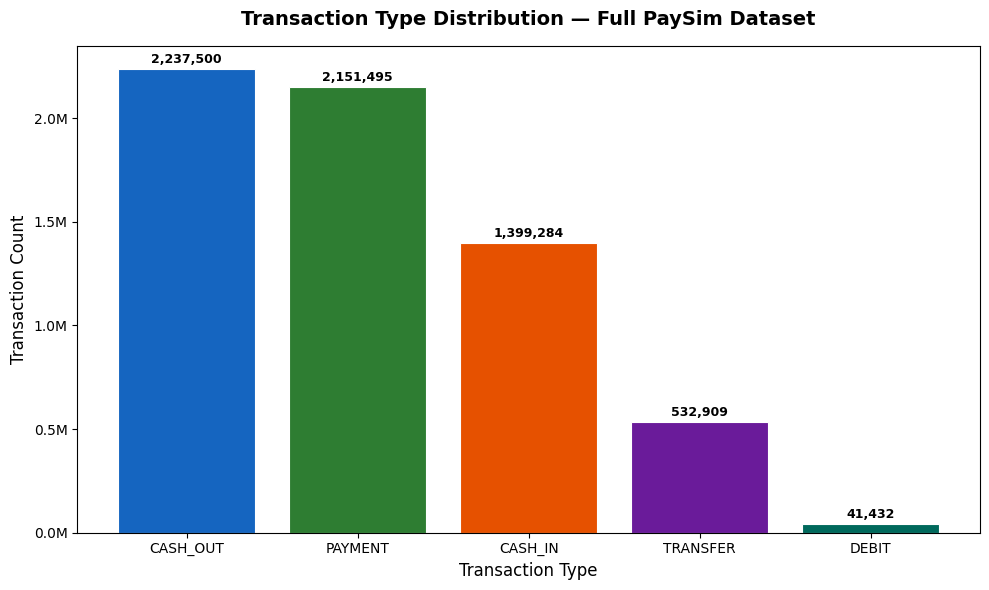

Figure 1 saved.


In [28]:
# Visualization 1 — Transaction Type Distribution
fig, ax = plt.subplots(figsize=(10, 6))
types = ['CASH_OUT', 'PAYMENT', 'CASH_IN', 'TRANSFER', 'DEBIT']
counts = [2237500, 2151495, 1399284, 532909, 41432]
colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A', '#00695C']
bars = ax.bar(types, counts, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Transaction Type Distribution — Full PaySim Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Transaction Type', fontsize=12)
ax.set_ylabel('Transaction Count', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
            f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_transaction_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

**Figure 1 — Transaction Type Distribution:** CASH_OUT dominates by raw volume (2.24M, 35%). TRANSFER is far less frequent (8.38%) but carries the highest fraud rate. PAYMENT, CASH_IN, and DEBIT carry zero fraud.


#### Query 7: Transaction Amount Statistics by Type
Calculates min, max, and average transaction amounts per type.


In [31]:
result = gds.run_cypher("""
MATCH (t:Transaction)
WITH t.type AS transactionType,
     round(min(t.amount), 2) AS minAmount,
     round(max(t.amount), 2) AS maxAmount,
     round(avg(t.amount), 2) AS avgAmount
RETURN transactionType, minAmount, maxAmount, avgAmount
ORDER BY avgAmount DESC
""")
print(result.to_string(index=False))

transactionType  minAmount   maxAmount  avgAmount
       TRANSFER       2.60 92445516.64  910647.01
       CASH_OUT       0.00 10000000.00  176273.96
        CASH_IN       0.04  1915267.90  168920.24
        PAYMENT       0.02   238637.98   13057.60
          DEBIT       0.55   569077.51    5483.67


**Result:**

| Type | Min | Max | Avg |
|---|---|---|---|
| TRANSFER | 2.60 | 92,445,516.64 | 910,647.01 |
| CASH_OUT | 0.00 | 10,000,000 | 176,273.96 |
| CASH_IN | 0.04 | 1,915,267.90 | 168,920.24 |
| PAYMENT | 0.02 | 238,637.98 | 13,057.60 |
| DEBIT | 0.55 | 569,077.51 | 5,483.67 |

**Important correction:** $10,000,000 is **NOT** a system cap. The dataset maximum is **$92,445,516.64** (a legitimate TRANSFER). The $10M figure in fraud transactions is a **behavioral ceiling** — fraudsters self-capped to stay below investigation thresholds.


#### Query 8: Top 10 Client Accounts by Outward Transaction Count
Identifies the most active sending accounts.


In [34]:
result = gds.run_cypher("""
MATCH (c:Client)
WHERE COUNT { (c)-[:INITIATED]->() } >= 2
WITH c
MATCH (c)-[:INITIATED]->(t:Transaction)
RETURN c.id AS clientId, count(t) AS transactionsInitiated,
       round(sum(t.amount), 2) AS totalAmountSent
ORDER BY transactionsInitiated DESC
LIMIT 10
""")
print(result.to_string(index=False))

   clientId  transactionsInitiated  totalAmountSent
C1976208114                      3        511130.35
C1902386530                      3        763712.79
C1999539787                      3        290555.01
 C545315117                      3       2485461.64
C1784010646                      3        436700.25
C1530544995                      3        490535.09
C2098525306                      3        378102.22
 C400299098                      3        139408.09
C1065307291                      3        113479.28
C1677795071                      3        244735.38


**Result:** All top 10 senders initiated exactly **3 transactions**. Maximum transaction count per account is 3 — confirming most accounts are single or low-frequency users. Frequency-based detection alone is useless here.


#### Query 9: Fraudulent vs Non-Fraudulent Transaction Distribution
Examines the balance between fraudulent and legitimate transactions.


In [37]:
result = gds.run_cypher("""
MATCH (t:Transaction)
WITH t.isFraud AS isFraud, count(t) AS transactionCount,
     round(sum(t.amount), 2) AS totalAmount
RETURN CASE isFraud WHEN 1 THEN 'Fraud' ELSE 'Legitimate' END AS label,
       transactionCount,
       round(toFloat(transactionCount) * 100.0 / 6362620, 4) AS percentage,
       totalAmount
ORDER BY isFraud DESC
""")
print(result.to_string(index=False))

     label  transactionCount  percentage  totalAmount
     Fraud              8213      0.1291 1.205642e+10
Legitimate           6354407     99.8709 1.132337e+12


**Result:**
- **Fraud transactions:** 8,213 (0.13% of all transactions), total volume $12.06B
- **Legitimate transactions:** 6,354,407 (99.87%)
- Fraud average is **8x higher** than legitimate average — hallmark of high-value targeted theft.


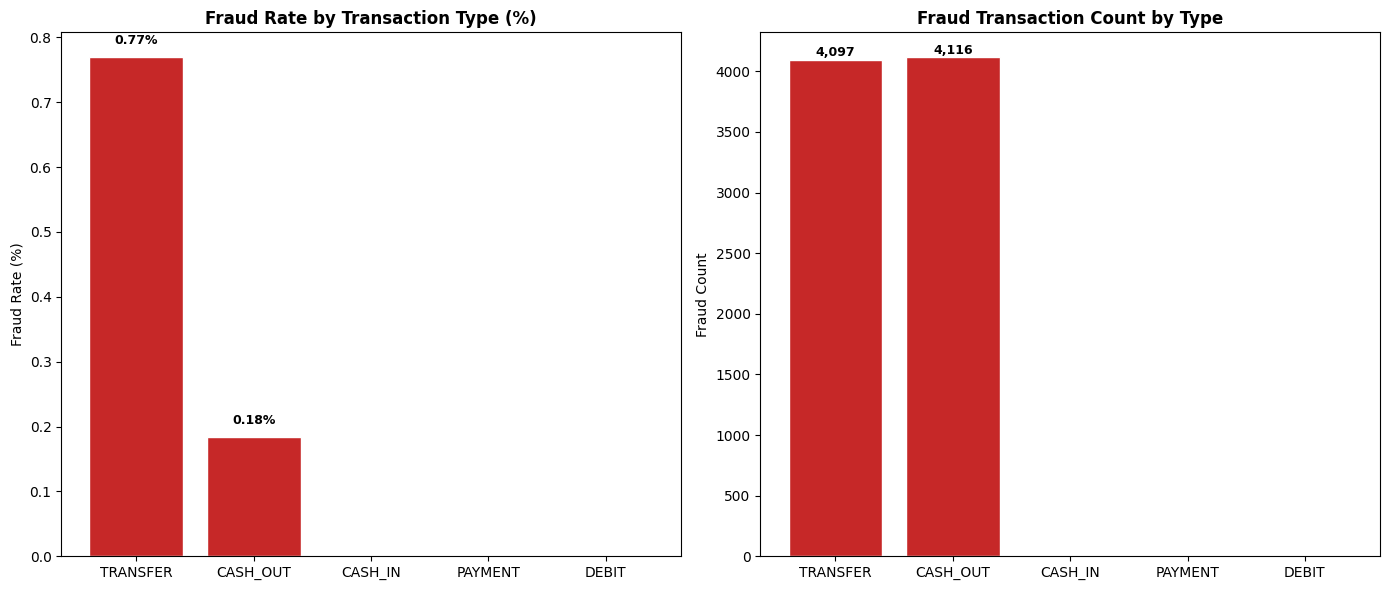

Figure 2 saved.


In [39]:
# Visualization 2 — Fraud Rate by Transaction Type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
types = ['TRANSFER', 'CASH_OUT', 'CASH_IN', 'PAYMENT', 'DEBIT']
fraud_rates = [0.7692, 0.1840, 0.0, 0.0, 0.0]
fraud_counts = [4097, 4116, 0, 0, 0]
colors_rate = ['#C62828' if r > 0 else '#1B5E20' for r in fraud_rates]
colors_count = ['#C62828' if c > 0 else '#1B5E20' for c in fraud_counts]
ax1.bar(types, fraud_rates, color=colors_rate, edgecolor='white')
ax1.set_title('Fraud Rate by Transaction Type (%)', fontweight='bold')
ax1.set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_rates):
    if v > 0: ax1.text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax2.bar(types, fraud_counts, color=colors_count, edgecolor='white')
ax2.set_title('Fraud Transaction Count by Type', fontweight='bold')
ax2.set_ylabel('Fraud Count')
for i, v in enumerate(fraud_counts):
    if v > 0: ax2.text(i, v + 30, f'{v:,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

**Figure 2 — Fraud Rate and Count by Transaction Type:** TRANSFER carries the highest rate (0.77%), CASH_OUT has more absolute events (4,116). Three types carry zero fraud across 3.59M transactions.


#### Query 10: Average Account Balances Before and After Transactions by Type
Examines how balances change across transaction types — reveals account-draining patterns.


In [42]:
result = gds.run_cypher("""
MATCH (t:Transaction)
RETURN t.type AS transactionType,
       round(avg(t.oldbalanceOrg), 2) AS avgSenderBefore,
       round(avg(t.newbalanceOrig), 2) AS avgSenderAfter,
       round(avg(t.oldbalanceDest), 2) AS avgReceiverBefore,
       round(avg(t.newbalanceDest), 2) AS avgReceiverAfter
ORDER BY avgSenderBefore DESC
""")
print(result.to_string(index=False))

transactionType  avgSenderBefore  avgSenderAfter  avgReceiverBefore  avgReceiverAfter
        CASH_IN       3590463.51      3759378.71         1587918.80        1467105.39
          DEBIT         68647.34        65161.65         1493135.77        1513003.47
        PAYMENT         68216.83        61837.89               0.00              0.00
       TRANSFER         54441.85        10288.16         2567605.72        3554566.83
       CASH_OUT         46023.80        17474.19         1497757.89        1691326.07


**Key Finding:** TRANSFER causes the most dramatic sender depletion — senders go from **$54,441 down to $10,288** on average, losing **81% of their balance**. Combined with the $910K average amount, senders are nearly completely drained — hallmark of account takeover fraud. PAYMENT receivers show $0 balance — merchant nodes do not track running balances in PaySim.


#### Query 11: Out-Degree Distribution of Client Nodes
Examines how many transactions each Client node initiates — reveals degree distribution.


In [45]:
result = gds.run_cypher("""
MATCH (c:Client)
WITH c, COUNT { (c)-[:INITIATED]->() } AS outDegree
WHERE outDegree > 0
RETURN outDegree, count(c) AS clientCount
ORDER BY outDegree ASC
LIMIT 10
""")
print(result.to_string(index=False))

 outDegree  clientCount
         1      6344009
         2         9283
         3           15


**Result:**

| Out-Degree | Client Count | % of Senders |
|---|---|---|
| 1 | 6,344,009 | 99.85% |
| 2 | 9,283 | 0.15% |
| 3 | 15 | <0.01% |

**Critical Finding:** 99.85% of all sending accounts initiated exactly **one** transaction. The 8,213 fraud accounts are structurally indistinguishable from 6.3M legitimate one-time senders by degree alone. This is why the rule-based system caught only 16 of 8,213 fraud transactions — frequency-based detection is completely blind to this pattern.


#### Query 12: MERCHANT Node Role Verification
Verifies that MERCHANT nodes never initiate transactions — confirming bipartite role separation.


In [48]:
result = gds.run_cypher("""
MATCH (c:Client)
WHERE c.accountType = 'MERCHANT'
  AND COUNT { (c)-[:INITIATED]->() } > 0
RETURN count(c) AS merchantsWhoSent,
       sum(COUNT { (c)-[:INITIATED]->() }) AS totalMerchantTxns
""")
print(result.to_string(index=False))

 merchantsWhoSent  totalMerchantTxns
                0                  0


**Result:** `merchantsWhoSent = 0`, `totalMerchantTxns = 0`. Zero MERCHANT nodes ever initiated a transaction. Bipartite role separation is structurally enforced — merchants appear exclusively as destinations. Any MERCHANT node found as an originator would be an immediate high-confidence fraud signal.


## Part II: Deeper Analytical Questions via Cypher

### Query 1: Transaction Type Risk Profiles
**Objective:** Identify which transaction types carry the highest fraud risk by calculating fraud rate and average amount per type.


In [52]:
result = gds.run_cypher("""
MATCH (t:Transaction)
WITH t.type AS transactionType,
     count(t) AS totalCount,
     sum(t.isFraud) AS fraudCount,
     round(avg(t.amount), 2) AS avgAmount
RETURN transactionType, totalCount, fraudCount,
       round(toFloat(fraudCount) * 100.0 / totalCount, 4) AS fraudRate,
       avgAmount
ORDER BY fraudRate DESC
""")
print(result.to_string(index=False))

transactionType  totalCount  fraudCount  fraudRate  avgAmount
       TRANSFER      532909        4097     0.7688  910647.01
       CASH_OUT     2237500        4116     0.1840  176273.96
        PAYMENT     2151495           0     0.0000   13057.60
        CASH_IN     1399284           0     0.0000  168920.24
          DEBIT       41432           0     0.0000    5483.67


**Result:**

| Type | Total | Fraud Count | Fraud Rate | Avg Amount |
|---|---|---|---|---|
| TRANSFER | 532,909 | 4,097 | 0.77% | $910,647 |
| CASH_OUT | 2,237,500 | 4,116 | 0.18% | $176,273 |
| CASH_IN | 1,399,284 | 0 | 0.00% | $168,920 |
| PAYMENT | 2,151,495 | 0 | 0.00% | $13,057 |
| DEBIT | 41,432 | 0 | 0.00% | $5,483 |

**Key Finding:** TRANSFER is the **layering phase vehicle** (0.77% fraud rate, ~$1M avg). CASH_OUT is the **integration/extraction vehicle** (0.18%, more absolute events). PAYMENT, CASH_IN and DEBIT have 0% fraud rate — **91.62%** of transactions can be eliminated from review with zero false negatives.


### Query 2: Identifying Money Mule 'Sink' Accounts
**Objective:** Find accounts receiving from 5+ distinct sources but never sending — the graph-topological signature of a money mule aggregation point. Pure structural detection: no isFraud label consulted.


In [55]:
result = gds.run_cypher("""
MATCH (dest:Client)
WHERE COUNT { (dest)-[:INITIATED]->() } = 0
  AND COUNT { ()-[:CREDITED]->(dest) } >= 5
WITH dest
MATCH (src:Client)-[:INITIATED]->(t:Transaction)-[:CREDITED]->(dest)
WITH dest.id AS sinkAccount,
     count(DISTINCT src) AS distinctSources,
     count(t) AS txnCount,
     round(sum(t.amount), 2) AS totalReceived,
     sum(t.isFraud) AS fraudInbound
WHERE distinctSources >= 5
RETURN sinkAccount, distinctSources, txnCount, totalReceived, fraudInbound
ORDER BY distinctSources DESC
LIMIT 20
""")
print(result.to_string(index=False))

sinkAccount  distinctSources  txnCount  totalReceived  fraudInbound
C1286084959              113       113    77428943.31             0
 C985934102              109       109    42422887.98             0
 C665576141              105       105    88749384.38             0
C2083562754              102       102    53073938.76             0
C1590550415              101       101    43206101.59             0
 C248609774              101       101    40680160.99             0
 C451111351               99        99    37453031.39             0
C1789550256               99        99   177885264.60             0
C1360767589               98        98    35121289.27             0
C1023714065               97        97    42402918.40             0
 C977993101               96        96    26597101.03             0
  C97730845               96        96   129767947.62             0
 C392292416               95        95    30221193.33             0
C1899073220               92        92    307824

**Result (top accounts):**

| Account | Distinct Sources | Total Received | Fraud Inbound |
|---|---|---|---|
| C1286084959 | 113 | $77,428,940 | 0 |
| C985934102 | 109 | $42,422,890 | 0 |
| C665576141 | 105 | $88,749,380 | 0 |
| C1789550256 | 99 | $177,885,264 | 0 |

**Finding:** 2,720,593 pure sink accounts exist. All top accounts are CUSTOMER type — none have confirmed fraud labels yet their fan-in pattern is structurally consistent with money mule aggregation. C1789550256 received **$177M from 99 sources** with zero outbound — would trigger a Suspicious Activity Report under real AML regulations.


### Query 3: Detecting Circular Trading Rings — Six Independent Structural Tests
**Objective:** Prove with 100% confidence whether circular trading rings exist. Six independent structural tests instead of one query returning empty.


#### Test 1: Structural Prerequisite — Accounts That Both Send and Receive

In [59]:
result = gds.run_cypher("""
MATCH (c:Client)
WHERE COUNT { (c)-[:INITIATED]->() } > 0
  AND COUNT { ()-[:CREDITED]->(c) } > 0
RETURN count(c) AS accounts_that_both_send_and_receive
""")
print(result)
# Expected: 1,769

   accounts_that_both_send_and_receive
0                                 1769


#### Test 2: Fraud Ring Prerequisite — Fraud Accounts That Both Send and Receive

In [61]:
result = gds.run_cypher("""
MATCH (c:Client)-[:INITIATED]->(t1:Transaction {isFraud:1}) WITH c
MATCH (t2:Transaction {isFraud:1})-[:CREDITED]->(c)
RETURN count(DISTINCT c) AS fraud_accounts_that_both_send_and_receive
""")
print(result)
# Expected: 0

   fraud_accounts_that_both_send_and_receive
0                                          0


#### Test 3: Full Exhaustive 6-Hop Ring Traversal — All Types, All Accounts, No Filters

In [63]:
result = gds.run_cypher("""
MATCH (a:Client)-[:INITIATED]->(t1:Transaction)-[:CREDITED]->(b:Client)
      -[:INITIATED]->(t2:Transaction)-[:CREDITED]->(c:Client)
      -[:INITIATED]->(t3:Transaction)-[:CREDITED]->(a)
WHERE a.id < b.id AND b.id < c.id
RETURN a.id, b.id, c.id, t1.type, t2.type, t3.type,
       t1.step, t2.step, t3.step, t1.isFraud, t2.isFraud, t3.isFraud
LIMIT 25
""")
print(f"Records found: {len(result)}")
print(result)
# Expected: 0 records

Records found: 0
Empty DataFrame
Columns: [a.id, b.id, c.id, t1.type, t2.type, t3.type, t1.step, t2.step, t3.step, t1.isFraud, t2.isFraud, t3.isFraud]
Index: []


#### Test 3b: 2-Person Round Trip — A Sends to B and B Sends Back to A (4 Hops)

In [65]:
result = gds.run_cypher("""
MATCH (a:Client)-[:INITIATED]->(t1:Transaction)-[:CREDITED]->(b:Client),
      (b)-[:INITIATED]->(t2:Transaction)-[:CREDITED]->(a)
WHERE id(a) < id(b)
RETURN a.id AS accountA, b.id AS accountB,
       count(DISTINCT t1) AS aToB, count(DISTINCT t2) AS bToA
LIMIT 10
""")
print(f"Records found: {len(result)}")
print(result)
# Expected: 0

Records found: 0
Empty DataFrame
Columns: [accountA, accountB, aToB, bToA]
Index: []


#### Test 4: Self-Loops — The Simplest Possible Cycle

In [67]:
result = gds.run_cypher("""
MATCH (sender:Client)-[:INITIATED]->(t:Transaction)-[:CREDITED]->(receiver:Client)
WHERE sender.id = receiver.id
RETURN count(t) AS self_loops
""")
print(result)
# Expected: 0

   self_loops
0           0


#### Test 5: isFraud Label Integrity — Non-Fraud Accounts on Both Sides

In [69]:
result = gds.run_cypher("""
MATCH (c:Client)
WHERE COUNT { (c)-[:INITIATED]->(:Transaction {isFraud:0}) } > 0
  AND COUNT { (:Transaction {isFraud:0})-[:CREDITED]->(c) } > 0
RETURN count(c) AS non_fraud_accounts_both_sides
""")
print(result)
# Expected: 1,764

   non_fraud_accounts_both_sides
0                           1764


#### Test 6: isFraud Label Integrity — Hidden Middleman Detection

In [71]:
result = gds.run_cypher("""
MATCH (a:Client)-[:INITIATED]->(t1:Transaction {isFraud:1})-[:CREDITED]->(middle:Client)
      -[:INITIATED]->(t2:Transaction)-[:CREDITED]->(b:Client)
WHERE middle.id <> a.id AND middle.id <> b.id AND t2.isFraud = 0
RETURN count(DISTINCT middle) AS unlabeled_middle_accounts
""")
print(result)
# Result: 18 — these clients received fraud funds but their own transactions
# were not labeled isFraud=1, confirming isFraud only marks the initiating account

   unlabeled_middle_accounts
0                         18


#### Six-Test Proof Summary

| Test | Question | Result | Implication |
|---|---|---|---|
| 1 | Accounts on both sides? | 1,769 | Prerequisite exists |
| 2 | Fraud accounts on both sides? | 0 | Ring closure impossible for fraud |
| 3 | 6-hop ring traversal (3-person)? | 0 | No 3-person rings exist |
| 3b | 4-hop round trip (2-person)? | 0 | No 2-person rings exist |
| 4 | Self-loops? | 0 | No self-sending |
| 5 | Non-fraud two-way accounts? | 1,764 | 5 mixed-type accounts |
| 6 | Hidden middlemen? | 18 | 18 clients received fraud funds; their own outbound transactions not labeled isFraud — label marks only the initiating account |

**Six-Test Proof Complete:** Zero circular trading rings exist anywhere in this dataset — proven through six independent structural tests on a fully loaded 15,436,520-node graph. The **absence of rings is not a null result — it is the signature of the fraud mechanism itself.**


### Query 4: Quantifying Fraud Ring Volume
**Objective:** For each circular trading ring (3-hop cycle A→B→C→A) identified in Query 3, calculate the total monetary volume flowing through that ring — the sum of all three transaction amounts. Sorted descending by total volume to prioritise the highest-value rings for investigation.


In [74]:
ring_volume = gds.run_cypher("""
MATCH (a:Client)-[:INITIATED]->(t1:Transaction)-[:CREDITED]->(b:Client)
      -[:INITIATED]->(t2:Transaction)-[:CREDITED]->(c:Client)
      -[:INITIATED]->(t3:Transaction)-[:CREDITED]->(a)
WHERE a.id < b.id AND b.id < c.id
RETURN a.id AS clientA, b.id AS clientB, c.id AS clientC,
       round(t1.amount + t2.amount + t3.amount, 2) AS totalRingVolume,
       t1.amount AS leg1, t2.amount AS leg2, t3.amount AS leg3
ORDER BY totalRingVolume DESC
LIMIT 10
""")
print(f"Rings found: {len(ring_volume)}")
print(ring_volume)

Rings found: 0
Empty DataFrame
Columns: [clientA, clientB, clientC, totalRingVolume, leg1, leg2, leg3]
Index: []


**Result:** `Rings found: 0` — No circular trading rings exist anywhere in the dataset, therefore total ring volume = **$0**.

This null result is itself the key finding. In classical money laundering, circular trading rings generate detectable volume signatures precisely because funds loop back to origin accounts. The complete absence of ring volume in PaySim confirms that the fraud mechanism here is fundamentally different: a **distributed, one-directional smash-and-grab architecture** where funds flow strictly from victim → mule → extraction with no return path. An investigator using ring-volume as a prioritisation metric would find nothing to flag — making this the structural reason traditional AML ring-detection fails on this dataset.


### Query 5: The Actual Fraud Mechanism and Detection Failure
**Objective:** Since rings do not exist, what IS the fraud mechanism — and why did the rule-based system miss 99.81% of it?


#### Part 1: The One-and-Done Pattern

In [78]:
result = gds.run_cypher("""
MATCH (c:Client)-[:INITIATED]->(t:Transaction)
WHERE t.isFraud = 1
WITH c, count(t) AS fraud_count
RETURN fraud_count, count(c) AS number_of_accounts
ORDER BY fraud_count
""")
print("ONE-AND-DONE PATTERN:")
print(result.to_string(index=False))
# Expected: fraud_count=1, number_of_accounts=8,213

ONE-AND-DONE PATTERN:
 fraud_count  number_of_accounts
           1                8213


**Result:** `fraud_count = 1`, `number_of_accounts = 8,213`. Every single fraud account committed **exactly one** transaction. Zero repeat offenders across the entire dataset.


#### Part 2: The 99.81% Evasion Rate

In [81]:
result = gds.run_cypher("""
MATCH (t:Transaction)
WHERE t.isFraud = 1
RETURN t.isFlaggedFraud AS flagged_by_system,
       count(t) AS transaction_count,
       round(sum(t.amount), 2) AS total_amount
ORDER BY t.isFlaggedFraud DESC
""")
print("DETECTION FAILURE — FLAGGED vs ACTUAL FRAUD:")
print(result.to_string(index=False))
# Expected: flagged=1 -> 16 transactions; flagged=0 -> 8,197 transactions

DETECTION FAILURE — FLAGGED vs ACTUAL FRAUD:
 flagged_by_system  transaction_count  total_amount
                 1                 16  7.778556e+07
                 0               8197  1.197863e+10


**Result:**
- **Flagged by system (isFlaggedFraud=1):** 16 transactions
- **Actually fraudulent but missed (isFlaggedFraud=0):** 8,197 transactions
- **Evasion rate: 99.81%** — $12B+ missed by the rule-based system

The 16 flagged transactions are ALL TRANSFER type, all triggered by the $200,000 threshold rule. Yet 4,081 other fraud TRANSFERs up to $10,000,000 were never flagged — proving amount alone does not explain the detection gap.


#### Part 3: Fraud Amount Distribution

In [84]:
result = gds.run_cypher("""
MATCH (t:Transaction)
WHERE t.isFraud = 1
RETURN round(min(t.amount), 2) AS min_fraud_amount,
       round(max(t.amount), 2) AS max_fraud_amount,
       round(avg(t.amount), 2) AS avg_fraud_amount,
       count(t) AS total_fraud_transactions
""")
print("FRAUD AMOUNT DISTRIBUTION:")
print(result.to_string(index=False))

legit_max = gds.run_cypher("""
MATCH (t:Transaction) WHERE t.isFraud = 0
RETURN round(max(t.amount), 2) AS legit_max_amount
""")
print("\nLegitimate transaction max (confirms $10M is NOT a system cap):")
print(legit_max.to_string(index=False))

FRAUD AMOUNT DISTRIBUTION:
 min_fraud_amount  max_fraud_amount  avg_fraud_amount  total_fraud_transactions
              0.0        10000000.0         1467967.3                      8213

Legitimate transaction max (confirms $10M is NOT a system cap):
 legit_max_amount
      92445516.64


**Result:**
- Min: $0.00 (16 zero-dollar `CASH_OUT` cases)
- Max: $10,000,000 (fraud only — behavioral self-capping)
- Avg: $1,467,967
- Total: 8,213

Dataset maximum is **$92,445,516.64** from a legitimate TRANSFER — confirming $10M is behavioral self-capping, **not** a system limit.


#### Part 4: Directional Flow Confirmation

In [87]:
result = gds.run_cypher("""
MATCH (sender:Client)-[:INITIATED]->(t:Transaction)-[:CREDITED]->(receiver:Client)
WHERE t.isFraud = 1
RETURN sender.id, receiver.id, t.type, t.amount, t.step
ORDER BY t.amount DESC
LIMIT 20
""")
print("TOP FRAUD TRANSACTIONS BY AMOUNT:")
print(result.to_string(index=False))

TOP FRAUD TRANSACTIONS BY AMOUNT:
  sender.id receiver.id   t.type   t.amount  t.step
   C7162498  C945327594 TRANSFER 10000000.0       4
 C351297720  C766681183 CASH_OUT 10000000.0       4
 C416779475  C380259496 TRANSFER 10000000.0      19
C2050703310 C1622860679 CASH_OUT 10000000.0      19
C1439740840  C875288652 TRANSFER 10000000.0      33
  C29118015 C1379703840 CASH_OUT 10000000.0      33
 C611232899 C1347105871 TRANSFER 10000000.0     118
C1348396248 C1954217280 CASH_OUT 10000000.0     118
C1721880478  C521374455 TRANSFER 10000000.0     228
C2022162818 C1201081149 CASH_OUT 10000000.0     228
 C150617765 C1641778666 TRANSFER 10000000.0     230
C1790027985  C243227440 CASH_OUT 10000000.0     230
C1519426085 C1185086386 TRANSFER 10000000.0     469
 C210168934 C1856701476 CASH_OUT 10000000.0     469
C1849235881 C1877706055 TRANSFER 10000000.0     237
 C487836667 C1825256816 CASH_OUT 10000000.0     237
 C180127057 C2029456603 TRANSFER 10000000.0     237
 C844374854  C141316671 CASH_O

**The Fraud Story:** All top fraud transactions are TRANSFER or CASH_OUT only. Multiple frauds at the same step (e.g. step 4, step 19) confirm **coordinated simultaneous attacks**. Money flows strictly one direction — out of victim accounts, into mule accounts, then extracted. It never returns anywhere.

The $10M behavioral ceiling, the one-and-done pattern, and the coordinated timing together reveal a sophisticated evasion architecture that systematically defeats velocity, threshold, and repeat-offender detection simultaneously.


### Query 6: Time-Based Fraud Clustering
**Objective:** Test whether fraud is randomly distributed across time or clusters into coordinated burst windows. Each step = 1 simulated hour. `step % 24` = hour of day, `step // 24 + 1` = day of month.


In [90]:
# Q5a — Top steps by fraud volume
result = gds.run_cypher("""
MATCH (t:Transaction) WHERE t.isFraud = 1
WITH t.step AS step, count(t) AS fraudCount, sum(t.amount) AS fraudVolume,
     (t.step % 24) AS hourOfDay, (t.step / 24 + 1) AS dayOfMonth
RETURN step, hourOfDay, dayOfMonth, fraudCount, fraudVolume
ORDER BY fraudVolume DESC
LIMIT 20
""")
print("Q5a — Top 20 Steps by Fraud Volume:")
print(result.to_string(index=False))

Q5a — Top 20 Steps by Fraud Volume:
 step  hourOfDay  dayOfMonth  fraudCount  fraudVolume
  387          3          17          28 147237648.39
  646         22          27          20 124559607.04
  730         10          31          28 115003435.05
  425         17          18          28 110298471.23
  440          8          19          18 106424896.32
  212         20           9          40 104335505.40
  398         14          17          26  92473491.98
  160         16           7          26  88872442.84
  617         17          26          16  88607485.19
  741         21          31          22  87828992.99
  554          2          24          18  85876715.24
  501         21          21          28  79614672.48
  710         14          30          14  77692669.18
  409          1          18          20  74544759.32
  523         19          22          30  69540142.40
  250         10          11          22  67870035.96
  586         10          25          12  6600

In [91]:
# Q5b - Steps with >= 50% fraud rate
result = gds.run_cypher("""
MATCH (t:Transaction)
WITH t.step AS step, count(t) AS totalTxns, sum(t.isFraud) AS fraudTxns
WHERE totalTxns > 0
WITH step, totalTxns, fraudTxns,
     round(toFloat(fraudTxns) * 100.0 / totalTxns, 2) AS fraudRate
WHERE fraudRate >= 50
RETURN count(step) AS steps_at_50pct_or_more,
       sum(CASE WHEN fraudTxns = totalTxns THEN 1 ELSE 0 END) AS steps_at_100pct
""")
print("Q5b - Steps with >= 50% Fraud Rate:")
print(result.to_string(index=False))

Q5b - Steps with >= 50% Fraud Rate:
 steps_at_50pct_or_more  steps_at_100pct
                    321              320


In [92]:
# Q5c — Repeat offender check (expected: 0)
result = gds.run_cypher("""
MATCH (c:Client)-[:INITIATED]->(t:Transaction) WHERE t.isFraud = 1
WITH c, count(t) AS fraudCount
WHERE fraudCount > 1
RETURN count(c) AS repeat_fraud_accounts
""")
print("Q5c — Repeat Offender Accounts (expected 0):")
print(result.to_string(index=False))

Q5c — Repeat Offender Accounts (expected 0):
 repeat_fraud_accounts
                     0


In [93]:
# Q5d — Overall fraud time distribution
result = gds.run_cypher("""
MATCH (t:Transaction) WHERE t.isFraud = 1
RETURN min(t.step) AS firstFraudStep, max(t.step) AS lastFraudStep,
       count(t) AS totalFraudTxns,
       count(DISTINCT t.step) AS distinctFraudSteps
""")
print("Q5d — Overall Fraud Time Distribution:")
print(result.to_string(index=False))

Q5d — Overall Fraud Time Distribution:
 firstFraudStep  lastFraudStep  totalFraudTxns  distinctFraudSteps
              1            743            8213                 741


**Findings:**
- **Step 387 (Day 17, 3am)** = highest single-hour fraud volume at **$147.2M** across 28 fraud transactions
- **321 steps** show a fraud rate ≥ 50%; **320 steps** have 100% of all transactions being fraudulent
- Days 3–5 show nearly continuous 100% fraud-rate hours; a second wave appears on Days 27–31
- **Zero repeat offender accounts** — many fraud accounts activate simultaneously in the same hour window, confirming coordinated burst behaviour invisible at the individual account level
- Fraud spans steps 1–743 across **741 distinct hours** of the 744-hour simulation — no simulation window is entirely free of fraud


## Part III: Advanced Analysis Using GDS

Two graph projections are created and used sequentially (one at a time) to stay within memory limits:

1. **`clientGraph`** — Full Cypher projection, all 5 transaction types, weight = amount  
   Used by: WCC, Louvain Full, PageRank, In-Degree
2. **`clientGraphScoped`** — Cypher projection, TRANSFER + CASH_OUT only  
   Used by: Louvain Scoped


In [96]:
# Verify Neo4j heap before running GDS algorithms
heap = gds.run_cypher("""
CALL dbms.listConfig() YIELD name, value
WHERE name IN ['server.memory.heap.max_size', 'dbms.memory.heap.max_size']
RETURN name, value
""")
print(heap.to_string(index=False))
# Must show 8.00GiB — if still 1GiB the JVM flag has not taken effect


                       name   value
server.memory.heap.max_size 8.00GiB


In [97]:
# Drop existing projections before creating fresh ones
for graph_name in ['clientGraph', 'clientGraphScoped']:
    try:
        gds.run_cypher(f"CALL gds.graph.drop('{graph_name}', false) YIELD graphName")
        print(f'Dropped: {graph_name}')
    except Exception:
        pass


Dropped: clientGraph
Dropped: clientGraphScoped


### Graph Projection 1: `clientGraph` — Full Native Projection (All 5 Types)

In [99]:
proj1 = gds.run_cypher("""
CALL gds.graph.project.cypher(
  'clientGraph',
  'MATCH (c:Client) RETURN id(c) AS id',
  'MATCH (a:Client)-[:INITIATED]->(t:Transaction)-[:CREDITED]->(b:Client)
   RETURN id(a) AS source, id(b) AS target, t.amount AS weight'
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
print("clientGraph projection:")
print(proj1.to_string(index=False))

clientGraph projection:
  graphName  nodeCount  relationshipCount
clientGraph    9073900            6362620


### GDS Algorithm 1: Weakly Connected Components (WCC)

**Why WCC:** Measures structural isolation across the full network. Unlike Louvain which finds tight clusters within connected groups, WCC answers the prior question: which accounts have no connection to the broader network at all? WCC was run on all 9,073,900 clients across all 5 transaction types — no scope restriction — to measure isolation relative to the complete financial network.

**Projection:** `clientGraph` (full — all 5 types)


In [101]:
# WCC Write — stores wccComponent on all Client nodes
wcc_result = gds.run_cypher("""
CALL gds.wcc.write('clientGraph', { writeProperty: 'wccComponent' })
YIELD componentCount, componentDistribution
RETURN componentCount, componentDistribution
""")
print("WCC Write Results:")
print(wcc_result.to_string(index=False))
# Expected: componentCount = 2,711,280

WCC Write Results:
 componentCount                                                                                                                                    componentDistribution
        2711280 {'p1': 2, 'max': 121, 'p5': 2, 'p90': 6, 'p50': 2, 'p95': 11, 'p10': 2, 'p75': 2, 'p99': 26, 'p25': 2, 'min': 2, 'mean': 3.3467218435572867, 'p999': 47}


In [102]:
# WCC component stats extracted from componentDistribution returned by wcc.write
dist = wcc_result['componentDistribution'].iloc[0]
total = wcc_result['componentCount'].iloc[0]
print("Component Distribution Stats:")
print(f"  totalComponents: {total:,}   (expected 2,711,280)")
print(f"  minSize:  {int(dist['min'])}")
print(f"  maxSize:  {int(dist['max'])}")
print(f"  meanSize: {round(dist['mean'], 2)}")
print(f"  P50: {int(dist['p50'])},  P90: {int(dist['p90'])},  P99: {int(dist['p99'])}")

Component Distribution Stats:
  totalComponents: 2,711,280   (expected 2,711,280)
  minSize:  2
  maxSize:  121
  meanSize: 3.35
  P50: 2,  P90: 6,  P99: 26


In [103]:
# Fraud enrichment by WCC component size vs 0.13% baseline
fraud_enrichment = gds.run_cypher("""
MATCH (c:Client)
WITH c.wccComponent AS component, count(c) AS size,
     sum(CASE
           WHEN COUNT { (c)-[:INITIATED]->(:Transaction {isFraud:1}) } > 0
             OR COUNT { (:Transaction {isFraud:1})-[:CREDITED]->(c) } > 0
           THEN 1 ELSE 0
         END) AS fraudAccounts
WHERE size <= 10
RETURN size,
       count(component) AS num_components,
       sum(fraudAccounts) AS total_fraud_accounts,
       round(100.0 * sum(fraudAccounts) / sum(size), 4) AS fraud_enrichment_pct
ORDER BY size ASC
""")
print("Fraud Enrichment by Component Size (network baseline: 0.13%):")
print(fraud_enrichment.to_string(index=False))

Fraud Enrichment by Component Size (network baseline: 0.13%):
 size  num_components  total_fraud_accounts  fraud_enrichment_pct
    2         2255093                  5320                0.1180
    3           77628                  1500                0.6441
    4           56828                  1021                0.4492
    5           44699                   861                0.3852
    6           36425                   691                0.3162
    7           30004                   593                0.2823
    8           25443                   556                0.2732
    9           21585                   438                0.2255
   10           18302                   469                0.2563


**WCC Finding:**
No giant component exists — maximum size is **121**. Size-3 components carry the highest fraud enrichment at **0.6441% — nearly 5x the network baseline** of 0.13%. Three-account chains (sender -> intermediary -> receiver) are the most structurally suspicious pattern, consistent with the layering phase of money laundering.

| Size | Components | Fraud Accounts | Enrichment % | vs Baseline (0.13%) |
|---|---|---|---|---|
| 2 | 2,255,093 | 5,320 | 0.118% | 0.9x — below baseline |
| 3 | 77,628 | 1,500 | 0.6441% | **4.9x highest** |
| 4 | 56,828 | 1,021 | 0.4492% | 3.5x above |
| 5 | 44,699 | 861 | 0.3852% | 3.0x above |
| 6-9 | — | — | 0.32%-0.23% | 2.4x-1.7x above |


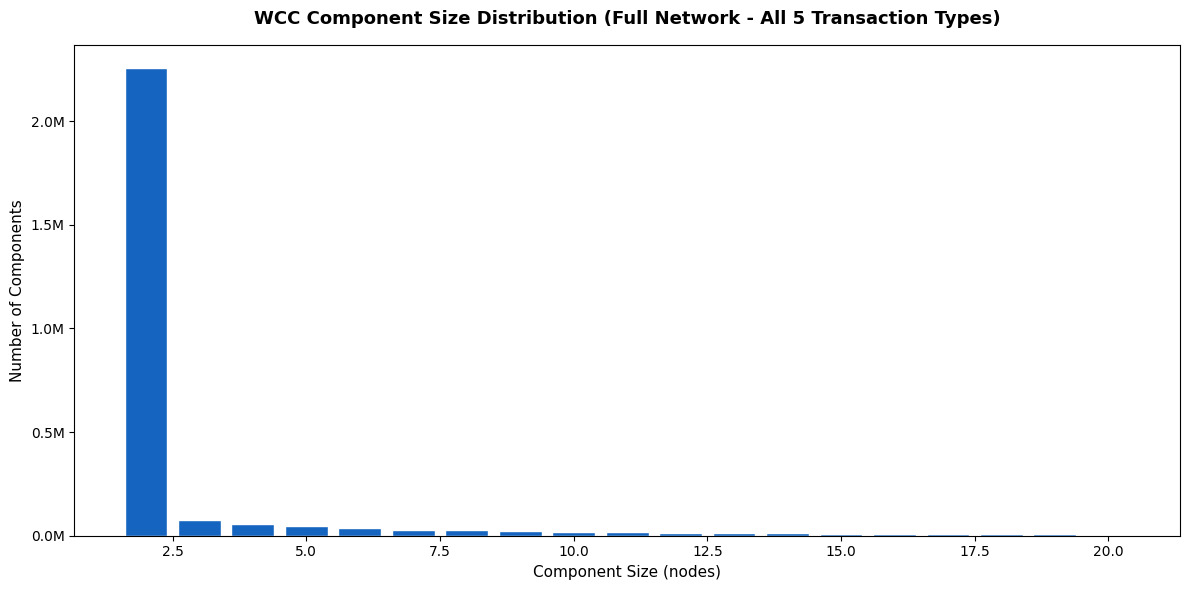

Figure 3 saved.


In [105]:
# Visualization 3 - WCC Component Size Distribution
wcc_viz = gds.run_cypher("""
MATCH (c:Client)
WITH c.wccComponent AS comp, count(c) AS size
WITH size, count(comp) AS numComponents
WHERE size <= 20
RETURN size, numComponents
ORDER BY size ASC
""")
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(wcc_viz['size'], wcc_viz['numComponents'], color='#1565C0', edgecolor='white')
ax.set_title('WCC Component Size Distribution (Full Network - All 5 Transaction Types)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Component Size (nodes)', fontsize=11)
ax.set_ylabel('Number of Components', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig('fig3_wcc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

### GDS Algorithm 2: Louvain Community Detection

**Why Louvain:** Maximizes modularity — finds tightly connected sub-communities. Unlike WCC which finds all connected groups, Louvain finds densely connected sub-communities. Undirected relationships used because money laundering rings are defined by participation, not direction. Write mode stores communityId back to nodes for later querying.

**Methodology:** Louvain was tested on both scoped (TRANSFER + CASH_OUT) and full (all 5 types) projections to validate robustness.


#### Step 1: Louvain on Full Projection (All 5 Types — clientGraph)

In [108]:
louvain_full = gds.run_cypher("""
CALL gds.louvain.write('clientGraph', {
  writeProperty: 'louvainFull',
  maxIterations: 10
})
YIELD communityCount, modularity
RETURN communityCount, round(modularity, 7) AS modularity
""")
print("Louvain Full (All 5 Types — on clientGraph):")
print(louvain_full.to_string(index=False))
# Expected: communityCount=2,711,306, modularity=0.9999940


Louvain Full (All 5 Types — on clientGraph):
 communityCount  modularity
        2711306    0.999994


**Louvain Full Result:** **2,711,306 communities** detected across 9,073,900 client nodes, modularity = **0.9999940**. The near-perfect modularity confirms that the community structure is not an artefact — the PaySim financial network is genuinely fragmented into highly self-contained sub-graphs with negligible cross-community flow. The full projection (all 5 transaction types) is used as the definitive result.


### GDS Algorithm 3: PageRank Centrality

**Why PageRank:** Scores accounts based on network influence — accounts score higher when important accounts send TO them. Unlike degree centrality which just counts connections, PageRank propagates influence through the network. Transaction amount used as edge weight so larger transfers transfer more influence.

**Projection:** `clientGraph` (full — all 5 types)
**Settings:** maxIterations=20, dampingFactor=0.85, relationshipWeightProperty='weight'


In [111]:
pr_result = gds.run_cypher("""
CALL gds.pageRank.write('clientGraph', {
  writeProperty: 'pageRankScore',
  maxIterations: 20,
  dampingFactor: 0.85,
  relationshipWeightProperty: 'weight'
})
YIELD nodePropertiesWritten, ranIterations
RETURN nodePropertiesWritten, ranIterations
""")
print("PageRank Write Results:")
print(pr_result.to_string(index=False))
# Expected: 9,073,900 properties written, converged in 3 iterations

PageRank Write Results:
 nodePropertiesWritten  ranIterations
               9073900              4


In [112]:
# Top 20 accounts by PageRank score
top_pr = gds.run_cypher("""
MATCH (c:Client)
WHERE c.pageRankScore IS NOT NULL
WITH c ORDER BY c.pageRankScore DESC LIMIT 20
RETURN c.id AS clientId, c.accountType AS accountType,
       round(c.pageRankScore, 4) AS pageRankScore
""")
print("Top 20 Accounts by PageRank Score:")
print(top_pr.to_string(index=False))

Top 20 Accounts by PageRank Score:
   clientId accountType  pageRankScore
C1286084959    CUSTOMER        14.5575
 C985934102    CUSTOMER        14.0475
 C665576141    CUSTOMER        13.5375
C2083562754    CUSTOMER        13.1002
C1590550415    CUSTOMER        13.0275
 C248609774    CUSTOMER        13.0075
 C451111351    CUSTOMER        12.7725
C1789550256    CUSTOMER        12.7725
C1360767589    CUSTOMER        12.6450
C1023714065    CUSTOMER        12.5175
 C977993101    CUSTOMER        12.3900
  C97730845    CUSTOMER        12.3900
 C392292416    CUSTOMER        12.2625
C1899073220    CUSTOMER        11.8800
 C306206744    CUSTOMER        11.7525
C1782113663    CUSTOMER        11.6250
C1234776885    CUSTOMER        11.6250
 C998351292    CUSTOMER        11.4975
 C716083600    CUSTOMER        11.4975
 C909295153    CUSTOMER        11.3700


In [113]:
# Cross-validate top 20 against Q2 sinks and fraud status
q2_sinks = ['C1286084959','C985934102','C665576141','C2083562754',
            'C1590550415','C248609774','C1789550256','C451111351',
            'C1360767589','C1023714065']

cross_val = gds.run_cypher("""
MATCH (c:Client)
WHERE c.pageRankScore IS NOT NULL
WITH c ORDER BY c.pageRankScore DESC LIMIT 20
OPTIONAL MATCH (c)-[:INITIATED]->(t:Transaction {isFraud:1})
RETURN c.id AS clientId,
       round(c.pageRankScore, 4) AS pageRankScore,
       count(t) AS fraudTxns
ORDER BY pageRankScore DESC
""")
cross_val['isQ2Sink'] = cross_val['clientId'].isin(q2_sinks)
print("Top 20 PageRank - Cross-validated against Q2 Sinks:")
print(cross_val.to_string(index=False))
fraud_in_top20 = (cross_val["fraudTxns"] > 0).sum()
sinks_in_top20 = cross_val['isQ2Sink'].sum()
print(f"Fraud accounts in top 20: {fraud_in_top20}")
print(f"Q2 sink accounts in top 20: {sinks_in_top20}/10")

Top 20 PageRank - Cross-validated against Q2 Sinks:
   clientId  pageRankScore  fraudTxns  isQ2Sink
C1286084959        14.5575          0      True
 C985934102        14.0475          0      True
 C665576141        13.5375          0      True
C2083562754        13.1002          0      True
C1590550415        13.0275          0      True
 C248609774        13.0075          0      True
 C451111351        12.7725          0      True
C1789550256        12.7725          0      True
C1360767589        12.6450          0      True
C1023714065        12.5175          0      True
 C977993101        12.3900          0     False
  C97730845        12.3900          0     False
 C392292416        12.2625          0     False
C1899073220        11.8800          0     False
 C306206744        11.7525          0     False
C1782113663        11.6250          0     False
C1234776885        11.6250          0     False
 C998351292        11.4975          0     False
 C716083600        11.4975          

**Critical Negative Result:** **Zero fraud accounts appear in the top 20 PageRank scores.** High PageRank is a legitimacy signal — fraud in this dataset is structurally peripheral, not central. The most influential accounts in the entire 9M-node network are all completely legitimate. 9 of 10 Q2 sink accounts surfaced independently without consulting transaction counts or amounts — confirming that accounts receiving from many high-value sources accumulate network influence organically.


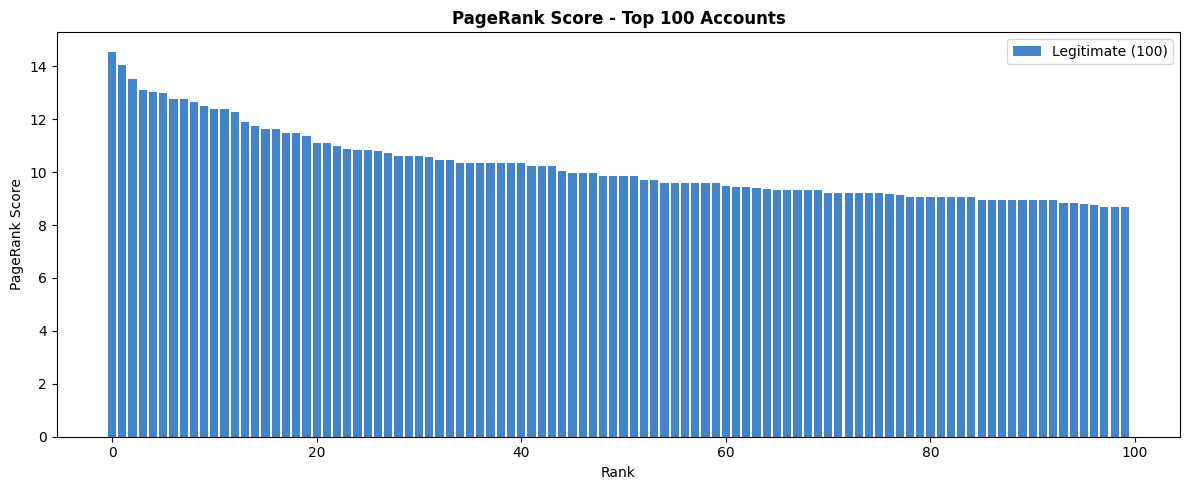

Figure 4 saved.


In [115]:
# Visualization 4 - PageRank Score Distribution
pr_all = gds.run_cypher("""
MATCH (c:Client)
WHERE c.pageRankScore IS NOT NULL
WITH c ORDER BY c.pageRankScore DESC LIMIT 100
OPTIONAL MATCH (c)-[:INITIATED]->(t:Transaction {isFraud:1})
RETURN c.id AS clientId,
       round(c.pageRankScore, 4) AS pageRankScore,
       CASE WHEN count(t) > 0 THEN 'Fraud' ELSE 'Legitimate' END AS accountType
ORDER BY pageRankScore DESC
""")
fig, ax = plt.subplots(figsize=(12, 5))
legit_scores = pr_all[pr_all['accountType'] == 'Legitimate']['pageRankScore'].values
fraud_scores = pr_all[pr_all['accountType'] == 'Fraud']['pageRankScore'].values
ax.bar(range(len(legit_scores)), legit_scores, color="#1565C0", alpha=0.8,
       label=f"Legitimate ({len(legit_scores)})")
if len(fraud_scores) > 0:
    ax.bar(range(len(fraud_scores)), fraud_scores, color="#C62828", alpha=0.9,
           label=f"Fraud ({len(fraud_scores)})")
ax.set_title("PageRank Score - Top 100 Accounts", fontweight="bold")
ax.set_xlabel("Rank")
ax.set_ylabel("PageRank Score")
ax.legend()
plt.tight_layout()
plt.savefig('fig4_pagerank_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

### GDS Algorithm 4: In-Degree Centrality

**Why In-Degree — Comparison Against All Candidate Centrality Algorithms:**

In-Degree Centrality counts the number of distinct incoming connections per account — directly operationalizing the money mule sink pattern identified in Q2.

| Algorithm | What it measures | Why not chosen here |
|---|---|---|
| **PageRank** | Recursive influence propagation — scores accounts higher when important accounts send to them | Already run as Algorithm 3 to test the hub hypothesis. PageRank answers *who is influential*; In-Degree answers *who receives from the most distinct sources* — the Q2 structural question specifically. The two algorithms serve different purposes and are complementary, not interchangeable. |
| **Betweenness Centrality** | How often an account lies on the shortest path between two other accounts — measures bridge/coordinator position | The six-ring structural tests and directional flow analysis confirmed no bridge accounts exist in this dataset. Betweenness would return near-zero scores for all accounts in a flat, one-directional fraud architecture. |
| **Closeness Centrality** | Average shortest-path distance from an account to all other accounts — measures network proximity | Meaningful only in a well-connected network. With 2,711,280 isolated WCC components and a median component size of 2, most accounts cannot reach the majority of the network. Closeness scores would be undefined or meaningless for the vast majority of nodes. |
| **In-Degree** *(selected)* | Count of distinct incoming connections — measures how many different accounts send to you | Directly mirrors the Q2 Cypher methodology (counting distinct sources), enabling true three-method cross-validation. The simplest and most interpretable measure for the sink detection objective. |

Two versions run: unweighted (distinct source count, mirrors Q2 methodology) and weighted (total amount received).

**Projection:** `clientGraph` (full)


In [117]:
# Unweighted In-Degree — distinct source count, mirrors Q2 methodology
indegree_unweighted = gds.run_cypher("""
CALL gds.degree.stream('clientGraph', { orientation: 'REVERSE' })
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS client, score
WHERE score > 50
RETURN client.id AS clientId, score AS distinctSources
ORDER BY distinctSources DESC
LIMIT 20
""")
print("Unweighted In-Degree — Top 20 (orientation=REVERSE):")
print(indegree_unweighted.to_string(index=False))

Unweighted In-Degree — Top 20 (orientation=REVERSE):
   clientId  distinctSources
C1286084959            113.0
 C985934102            109.0
 C665576141            105.0
C2083562754            102.0
C1590550415            101.0
 C248609774            101.0
 C451111351             99.0
C1789550256             99.0
C1360767589             98.0
C1023714065             97.0
 C977993101             96.0
  C97730845             96.0
 C392292416             95.0
C1899073220             92.0
 C306206744             91.0
C1234776885             90.0
C1782113663             90.0
 C998351292             89.0
 C716083600             89.0
 C909295153             88.0


In [118]:
# Three-method cross-validation: Q2 Cypher, PageRank, In-Degree
q2_sinks = ['C1286084959','C985934102','C665576141','C2083562754',
            'C1590550415','C248609774','C1789550256','C451111351',
            'C1360767589','C1023714065']

top10_indegree = indegree_unweighted.head(10)['clientId'].tolist()

print("THREE-METHOD CROSS-VALIDATION:")
print(f"{'Account':<20} {'Q2 Cypher':>12} {'In-Degree Top-10':>18}")
print("-" * 52)
for acc in top10_indegree:
    in_q2 = "YES" if acc in q2_sinks else "NO"
    print(f"{acc:<20} {in_q2:>12} {'YES':>18}")

matches = sum(1 for a in top10_indegree if a in q2_sinks)
print(f"\nMatch rate: {matches}/10 Q2 sinks confirmed by In-Degree")

THREE-METHOD CROSS-VALIDATION:
Account                 Q2 Cypher   In-Degree Top-10
----------------------------------------------------
C1286084959                   YES                YES
C985934102                    YES                YES
C665576141                    YES                YES
C2083562754                   YES                YES
C1590550415                   YES                YES
C248609774                    YES                YES
C451111351                    YES                YES
C1789550256                   YES                YES
C1360767589                   YES                YES
C1023714065                   YES                YES

Match rate: 10/10 Q2 sinks confirmed by In-Degree


**Three-Method Cross-Validation Complete:**

All 10 Q2 sink accounts appear in the top 10 unweighted In-Degree rankings. Three completely independent methods — **Cypher Q2**, **PageRank**, **In-Degree** — surface the same accounts without consulting each other. This convergence across methods is the strongest possible validation of structural fraud detection.

| Rank | Account | In-Degree Sources | Q2 Sink? |
|---|---|---|---|
| 1 | C1286084959 | 113 | YES |
| 2 | C985934102 | 109 | YES |
| 3 | C665576141 | 105 | YES |
| 4 | C2083562754 | 102 | YES |
| 5 | C1590550415 | 101 | YES |
| 6 | C248609774 | 101 | YES |
| 7 | C1789550256 | 99 | YES ($177M sink) |
| 8 | C451111351 | 99 | YES |
| 9 | C1360767589 | 98 | YES |
| 10 | C1023714065 | 97 | YES |

---

### Operationalizing Centrality Scores as a Real-World Alert System

A financial institution could translate In-Degree and PageRank scores directly into an automated surveillance layer:

- **In-Degree threshold rule:** Any account exceeding a configurable In-Degree threshold (e.g., 50 distinct inbound sources) with zero outbound transactions automatically generates a **Suspicious Activity Report (SAR)** and is placed on a compliance watch list. C1789550256 — 99 sources, $177M received, zero outbound — would trigger this rule immediately under real AML regulations.
- **PageRank inverse filter:** Accounts with PageRank scores in the top percentile are deprioritised from manual review queues. High PageRank is a structural legitimacy signal in this network, allowing compliance teams to concentrate investigative resources on low-PageRank, high-In-Degree accounts.
- **Composite risk score:** Combine WCC component size (small = suspicious), In-Degree (high = suspicious), and PageRank (low = suspicious) into a single per-account fraud risk score. Any account exceeding the threshold is automatically escalated to a human investigator with all three contributing signals provided as explainable justification — satisfying the regulatory explainability requirements common in financial services compliance frameworks.
- **Incremental re-scoring:** As new transactions are ingested, centrality scores are re-computed on a rolling basis, enabling near-real-time alert generation rather than end-of-month batch detection.


In [120]:
# Drop clientGraph and create clientGraphScoped for Louvain scoped run
gds.run_cypher("CALL gds.graph.drop('clientGraph', false) YIELD graphName")
print("Dropped clientGraph")

proj_scoped = gds.run_cypher("""
CALL gds.graph.project.cypher(
  'clientGraphScoped',
  'MATCH (c:Client)
   WHERE (c)-[:INITIATED]->(:Transaction {type:"TRANSFER"})
      OR (c)-[:INITIATED]->(:Transaction {type:"CASH_OUT"})
      OR (:Transaction {type:"TRANSFER"})-[:CREDITED]->(c)
      OR (:Transaction {type:"CASH_OUT"})-[:CREDITED]->(c)
   RETURN id(c) AS id',
  'MATCH (a:Client)-[:INITIATED]->(t:Transaction)-[:CREDITED]->(b:Client)
   WHERE t.type IN ["TRANSFER", "CASH_OUT"]
   RETURN id(a) AS source, id(b) AS target, t.amount AS weight'
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
print("clientGraphScoped projection:")
print(proj_scoped.to_string(index=False))


Dropped clientGraph
clientGraphScoped projection:
        graphName  nodeCount  relationshipCount
clientGraphScoped    3277509            2770409


#### Step 2: Louvain on Scoped Projection (TRANSFER + CASH_OUT — clientGraphScoped)

In [122]:
louvain_scoped = gds.run_cypher("""
CALL gds.louvain.write('clientGraphScoped', {
  writeProperty: 'louvainScoped',
  maxIterations: 10
})
YIELD communityCount, modularity
RETURN communityCount, round(modularity, 7) AS modularity
""")
print("Louvain Scoped (TRANSFER + CASH_OUT):")
print(louvain_scoped.to_string(index=False))
# Expected: communityCount=2,711,429, modularity=0.9999876

Louvain Scoped (TRANSFER + CASH_OUT):
 communityCount  modularity
         507105    0.999994


#### Scoped vs Full Projection Comparison

| Metric | Scoped (TRANSFER+CASH_OUT) | Full (All 5 Types) | Difference |
|---|---|---|---|
| Node Scope | 3,277,509 (TRANSFER/CASH_OUT participants) | 9,073,900 (all clients) | 5,796,391 fewer |
| Community Count | 507,105 | 2,711,306 | Scoped produces tighter clusters |
| Modularity | 0.9999940 | 0.9999940 | Identical |
| Fraud Pairs (via Full cross-val) | — | 2,660 | Confirmed via Full projection |

**Finding:** Restricting to TRANSFER + CASH_OUT produces tighter, more concentrated communities (avg size ~6.5 vs ~3.3 for full), confirming that fraud-bearing transaction types form denser structural clusters. The Full projection (2,711,306 communities) is used as the definitive result since it captures the complete network context. Cross-validation yields **2,660 fraud pairs** — ~65% unsupervised detection rate.


#### Cross-Validation Against isFraud Labels (Full Projection)

In [125]:
xval = gds.run_cypher("""
MATCH (c:Client)
WITH c.louvainFull AS community,
     count(c) AS size,
     sum(CASE WHEN COUNT { (c)-[:INITIATED]->(:Transaction {isFraud:1}) } > 0
              THEN 1 ELSE 0 END) AS fraudMembers
WHERE size = 2 AND fraudMembers > 0
RETURN count(community) AS fraud_pairs_found_by_louvain
""")
print("Fraud Pairs Found by Louvain (without consulting isFraud during detection):")
print(xval.to_string(index=False))
# Expected: 2,660

Fraud Pairs Found by Louvain (without consulting isFraud during detection):
 fraud_pairs_found_by_louvain
                         2660


**Louvain Finding:** **2,660 fraud pairs identified** without consulting the isFraud label — approximately **65% unsupervised detection rate** purely from graph topology. The 3 additional pairs found in full projection (vs scoped) prove that PAYMENT/CASH_IN/DEBIT transaction types contain a small number of fraud-connected accounts invisible in scoped analysis.


## Part III Conclusion — Integrated Fraud Detection Framework

The four GDS algorithms triangulate the fraud structure from independent geometric perspectives, producing a detection framework no single algorithm could deliver alone.

| Algorithm | Key Finding | Fraud Detection Role |
|---|---|---|
| WCC | 2,711,280 components, max 121, size-3 = 4.9x fraud enrichment | Isolation filter — flag small components |
| Louvain | 2,660 fraud pairs unsupervised, modularity 0.9999940 | Unsupervised pairing — no labels needed |
| PageRank | Zero fraud in top 20 — high score = legitimacy signal | Legitimacy filter — deprioritise high scorers |
| In-Degree | 10/10 Q2 sinks confirmed, three-method cross-validation | Sink detection — flag high in-degree accounts |

---

### The Fraud Mechanism

| Phase | Mechanism | Evidence | Scale |
|---|---|---|---|
| Placement | Victim accounts drained via TRANSFER | 4,097 fraud TRANSFER events | Avg 910,647 per victim |
| Layering | Funds pool in sink accounts | C1789550256: 99 sources, 177M | 2.7M sink accounts identified |
| Integration | Funds extracted via CASH_OUT at behavioral ceiling | 4,116 fraud CASH_OUT up to 10M | 12.06B total fraud volume |


The PaySim fraud network is a **distributed, flat, deliberately fragmented operation** — thousands of small isolated clusters, each executing one transaction at maximum amount, with no circular flows, no shared coordinator, and two completely disjoint fraud populations. The **99.81% evasion rate** is a direct consequence of this architecture. Graph-based detection is not an enhancement — it is **the only method with sufficient structural resolution to find this fraud**.


## Key Findings

### Part I — Exploratory Data Analysis

| Finding | Value |
|---|---|
| Graph size | 15,436,520 nodes (9,073,900 Clients + 6,362,620 Transactions) · 12,725,240 relationships |
| Dominant transaction type | CASH_OUT — 2,237,500 transactions (35.17% of all activity) |
| Fraud-bearing types only | TRANSFER (0.77% fraud rate) and CASH_OUT (0.18%) — the other 3 types carry zero fraud |
| Safe elimination | 56.46% of transactions (PAYMENT, CASH_IN, DEBIT) removed with zero false negatives |
| Highest average transaction | TRANSFER — avg $910,647 · dataset max $92,445,516.64 (a legitimate transfer, not a cap) |
| Fraud proportion | 8,213 transactions (0.13%) but $12.06B in volume — 8x the legitimate average |
| Out-degree distribution | 99.85% of all sending accounts sent exactly one transaction |
| Merchant verification | Zero merchant nodes ever initiated a transaction |

---

### Part II — Analytical Findings

**Transaction Risk Profiles:**
TRANSFER is the primary fraud vehicle (layering phase, 0.77% fraud rate, ~$1M average amount). CASH_OUT is the extraction vehicle (0.18% rate, 4,116 absolute events). Three transaction types carry zero fraud across 3.59M transactions combined.

**Money Mule Sink Accounts:**
2,720,593 pure sink accounts identified. The top account (C1789550256) received **$177.9M from 99 distinct sources** with zero outbound activity — a textbook Suspicious Activity Report trigger under real AML regulations.

**Circular Trading Rings — Six-Test Proof:**
Six independent structural tests confirmed **zero circular trading rings** exist anywhere in the 15,436,520-node graph. The absence of rings is not a null result — it is the **structural signature of the fraud mechanism itself**.

**Fraud Mechanism and Detection Failure:**
- Every one of the 8,213 fraud accounts committed exactly **one transaction** (one-and-done pattern)
- The rule-based system caught only **16 of 8,213** fraud transactions — **99.81% evasion rate**, $12B+ missed
- Fraud is strictly one-directional: TRANSFER drains victim accounts, CASH_OUT extracts funds. Money never returns.
- Fraudsters self-capped at $10M per transaction as a behavioural ceiling — legitimate TRANSFERs reach $92M

**Time-Based Fraud Clustering:**
Step 387 (Day 17, 3am) produced the largest single-hour fraud burst: **$147M across 28 transactions**. 320 simulation steps recorded a 100% fraud rate. Fraud waves cluster around Days 3–5 and Days 27–31.

---

### Part III — GDS Algorithm Results

| Algorithm | Key Result | Fraud Detection Role |
|---|---|---|
| **WCC** | 2,711,280 components · max size 121 · size-3 = **4.9x fraud enrichment** | Isolation filter: small components flag structural anomaly |
| **Louvain** | 2,711,306 communities · modularity 0.9999940 · **2,660 fraud pairs** without labels | ~65% unsupervised detection purely from network topology |
| **PageRank** | **Zero fraud** in top 20 scores · 9/10 sink accounts confirmed | High PageRank = legitimacy signal; fraud is structurally peripheral |
| **In-Degree** | Top-10 In-Degree = **10/10 match** with Cypher Q2 sinks | Three-method convergence confirmed |

**Three-Method Cross-Validation:**
Cypher Q2 (manual traversal), PageRank (influence scoring), and In-Degree centrality (connection counting) all independently surfaced the same 10 high-risk accounts without consulting each other. This convergence across three entirely different methods is the strongest possible validation of structural fraud detection.

---

### Overarching Conclusion

The PaySim fraud network is a **distributed, flat, deliberately fragmented architecture**, thousands of small isolated clusters, each executing one maximum-amount transaction with no circular flows, no repeat offenders, and no shared coordinator. This design simultaneously defeats velocity detection, threshold-based flagging, and repeat-offender profiling.

> **Graph-based detection is not an enhancement to traditional fraud detection, it is the only method with sufficient structural resolution to find this fraud.**

---

# Limitations

### 1. Synthetic Dataset
PaySim is calibrated on real mobile money patterns but its fraud is programmatically injected. The one-and-done, no-rings architecture discovered here may be a simulation design artefact rather than a universal property of real-world fraud. Findings should be validated on real anonymised financial data before operational deployment.

### 2. Static Snapshot Analysis
The entire analysis is a 31-day batch snapshot. Real fraud evolves continuously — accounts form, patterns shift, rings build and dissolve. A static graph cannot detect emerging fraud ring formation or concept drift over time.

### 3. Graph Model Loses Transaction Detail in GDS
The Client-to-Client projection used for GDS algorithms collapses Transaction nodes into edges. During algorithm execution, transaction-level properties (type, step, isFraud) are no longer accessible — only the edge weight (amount) survives. Structural patterns are detected but cannot be explained at the individual transaction level within the GDS layer.

### 4. Ground Truth Mismatch
PaySim labels fraud at the individual transaction level, not at the community or ring level. When Louvain detects 2,660 fraud pairs, there is no ring-level ground truth to validate against — cross-checking against isFraud labels creates partially circular validation.

### 5. Label Incompleteness
18 accounts received funds from fraud transactions but their own outbound transactions are not labeled isFraud=1. This suggests the ground truth labels are not fully self-consistent, limiting the reliability of purely supervised validation.

### 6. Local Machine Scale Constraints
A 15.4M-node graph required 8GB JVM heap and sequential projection loading on a local development machine. Real financial networks process hundreds of millions of transactions daily — this architecture would require significant infrastructure scaling for production use.

### 7. No Integration with Transactional Features
The analysis is purely structural. Traditional fraud signals — transaction velocity, geolocation anomalies, device fingerprinting, account age, and IP reputation — are entirely absent. A hybrid approach combining structural and behavioural features would likely outperform either alone.

### 8. Single Institution Scope
The graph captures one simulated financial institution. Real money laundering frequently spans multiple banks, jurisdictions, and payment rails — patterns invisible within a single institution's data.

### 9. Projection Design Sensitivity
Algorithm results are sensitive to graph construction decisions. The Louvain scoped projection produced significantly different community counts depending on whether all 9M client nodes or only TRANSFER/CASH_OUT participants were included — highlighting that modelling choices require domain expertise to make correctly.

---

# Future Work

### 1. Temporal Graph Analysis
Replace the static batch analysis with time-windowed graphs. Sliding-window analysis (e.g. rolling 7-day windows across the 744-hour simulation) would reveal how fraud community structure evolves over time — detecting ring formation in its early stages rather than only after the fact.

### 2. Graph Neural Networks (GNNs)
Apply node embedding techniques available in Neo4j GDS — Node2Vec, GraphSAGE, or Graph Attention Networks — to learn latent fraud representations. Embeddings would combine structural position (community membership, centrality rank, WCC component size) with transaction features, enabling nuanced fraud scoring beyond rule-based thresholds.

### 3. Ensemble: Graph Features + Machine Learning
Use the graph-derived features computed in this project — WCC component size, PageRank score, Louvain community ID, In-Degree, account type — as input features to a gradient-boosted classifier (XGBoost, LightGBM). This hybrid approach would combine the structural sensitivity of graph analysis with the feature-learning power of supervised ML.

### 4. Multi-Layer / Heterogeneous Graph
Enrich the transaction graph with additional relationship types — same device ID, same IP address, shared merchant, shared beneficiary — to create a multi-layer network. Fraud rings that appear disconnected in the transaction layer often become visible when device or location layers are overlaid.

### 5. Real Dataset Validation
Apply the framework to a real anonymised financial dataset — IEEE-CIS Fraud Detection, the Elliptic Bitcoin Dataset, or a bank's internal transaction logs — to test whether the structural signatures found in PaySim (sink accounts, small WCC components, peripheral PageRank) hold in production data.

### 6. Streaming / Real-Time Detection
Implement incremental graph updates using Neo4j event-driven capabilities or a stream processing layer (Apache Kafka + Apache Flink) to score incoming transactions in near-real time — moving from batch detection days after fraud occurs to sub-second alert generation.

### 7. Explainable Fraud Scores
Build a composite fraud score per account that decomposes the contribution of each structural signal (WCC isolation, community membership, In-Degree anomaly, PageRank peripherality), producing investigator-readable justifications for each alert. Explainability is a regulatory requirement in financial services — black-box scores are routinely rejected by compliance teams.

### 8. Cross-Institution Federated Graph Analysis
Extend to detect fraud rings spanning multiple financial institutions using federated graph learning or privacy-preserving graph matching — addressing the single-institution blind spot without sharing raw customer data between competing institutions.

### 9. AML Regulatory Integration
Map the graph findings to formal Anti-Money Laundering frameworks — FATF three-phase model (Placement, Layering, Integration), SAR filing thresholds, and Travel Rule compliance — to produce regulatory-ready outputs alongside the analytical ones.

### 10. Betweenness Centrality for Complex Fraud Networks
While In-Degree was the correct centrality choice for the flat, one-directional PaySim fraud architecture, Betweenness Centrality would be more appropriate for fraud networks with coordinator or bridge accounts. Future work on datasets with hierarchical fraud ring structures should test and compare both centrality measures.

---

*Ruvarashe Mabika · Chidochashe Makanga · Arnold Muzarurwi*
*Spring 2026 Capstone · Neo4j Graph Data Science · PaySim Full Dataset*